### Loading our libraries


In [13]:
!pip install --upgrade gspread gspread-dataframe

import requests
import pandas as pd
import gspread
import re
import csv
from google.auth import default
from gspread_dataframe import get_as_dataframe
from google.colab import auth
auth.authenticate_user()

import statsmodels.api as sm
from sklearn.model_selection import train_test_split

### Loading OMDb API key

In [14]:
OMDB_API_KEY = '4a36d174'

### Popular movies categorized manually by genre ans saved as a dictionary

In [15]:
genre_movies = {
    "Action": ["Mad Max: Fury Road", "John Wick", "The Dark Knight"],
    "Drama": ["Forrest Gump", "The Shawshank Redemption", "The Godfather"],
    "Comedy": ["Superbad", "The Hangover", "Step Brothers"],
    "Horror": ["Hereditary", "The Conjuring", "A Quiet Place"],
    "Science Fiction": ["Inception", "Interstellar", "The Matrix"]
}

###Initiate a new list to store the results

In [16]:
results = []

###Use the API key and query the OMDB site for each movie

In [17]:
for genre, titles in genre_movies.items():
    for title in titles:
        params = {
            't': title,
            'apikey': OMDB_API_KEY
        }
        response = requests.get("http://www.omdbapi.com/", params=params)
        data = response.json()

        if data["Response"] == "True":
            results.append({
                "Title": data.get("Title"),
                "Genre": genre,
                "IMDb Rating": data.get("imdbRating"),
                "Year": data.get("Year"),
                "Director": data["Director"],
                'Actors': data['Actors'],
            })
        else:
            print(f"Error fetching data for: {title}")


Save the results into a csv file

In [ ]:
csv_filename = "movies.csv"

with open(csv_filename, mode="w", newline='', encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["Title", "Genre", "IMDb Rating", "Year", "Director", "Actors"])
    writer.writeheader()
    writer.writerows(results)

print(f"Saved {len(results)} movie records to {csv_filename}")


Saved 15 movie records to movies.csv


View your data

In [18]:
movies= pd.read_csv('movies.csv')
movies

,Title,Genre,IMDb Rating,Year,Director,Actors
0,Mad Max: Fury Road,Action,8.1,2015,George Miller,"Tom Hardy, Charlize Theron, Nicholas Hoult"
1,John Wick,Action,7.4,2014,Chad Stahelski,"Keanu Reeves, Michael Nyqvist, Alfie Allen"
2,The Dark Knight,Action,9.0,2008,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart"
3,Forrest Gump,Drama,8.8,1994,Robert Zemeckis,"Tom Hanks, Robin Wright, Gary Sinise"
4,The Shawshank Redemption,Drama,9.3,1994,Frank Darabont,"Tim Robbins, Morgan Freeman, Bob Gunton"
5,The Godfather,Drama,9.2,1972,Francis Ford Coppola,"Marlon Brando, Al Pacino, James Caan"
6,Superbad,Comedy,7.6,2007,Greg Mottola,"Michael Cera, Jonah Hill, Christopher Mintz-Pl..."
7,The Hangover,Comedy,7.7,2009,Todd Phillips,"Zach Galifianakis, Bradley Cooper, Justin Bartha"
8,Step Brothers,Comedy,6.9,2008,Adam McKay,"Will Ferrell, John C. Reilly, Mary Steenburgen"
9,Hereditary,Horror,7.3,2018,Ari Aster,"Toni Collette, Milly Shapiro, Gabriel Byrne"


In [19]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        15 non-null     object 
 1   Genre        15 non-null     object 
 2   IMDb Rating  15 non-null     float64
 3   Year         15 non-null     int64  
 4   Director     15 non-null     object 
 5   Actors       15 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 852.0+ bytes


### Authenticate and authorize access to the spread sheet and read survey results

In [20]:
creds, _ = default()
gc = gspread.authorize(creds)
sheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/1ACefUWQoK0XxXYmvUX4N3F3cBrNzzrj6FNR9ArXR55E/edit?gid=390757334#gid=390757334')
worksheet = sheet.worksheet('Form Responses')
survey_data = get_as_dataframe(worksheet)

# See your data
survey_data.head()

,Timestamp,What is your gender?,What is your age group?,What is your preferred platform for watching a movie?,Do you rely more on public ratings or reviews from critics?,What is your minimum acceptable IMDb rating when deciding to watch a movie?,How many movies do you watch in a month on average?,How much do you trust IMDb ratings as a reflection of a movie's quality?,Have you skipped a movie solely because of a low rating?,Have you ever enjoyed a movie that had a low rating?,...,Rank each of these factors from 1-5 based on what matters most to you when picking a movie (where 1 being your top choice)? [Release Year],Rank each of these factors from 1-5 based on what matters most to you when picking a movie (where 1 being your top choice)? [Director],Rank each of these factors from 1-5 based on what matters most to you when picking a movie (where 1 being your top choice)? [Actors],"Given the details of Title, IMDb Rating, Year of Release, Director and Actor, Which of the following movies would you pick?","Given the details of Title, IMDb Rating, Year of Release, Director and Actor, Which of the following movies would you pick?.1","Given the details of Title, IMDb Rating, Year of Release, Director and Actor, Which of the following movies would you pick?.2","If a movie has a rating of 5.5 but your favorite actor stars in it, would you still watch it?","If a movie has a 9.5 rating but it's a genre you usually avoid, would you still give it a try?",Would a well-known director make you more willing to watch a movie in a genre you don’t usually enjoy?,"If a movie from your favorite genre had a bad IMDb score, would you skip it or still give it a shot?"
0,4/18/2025 22:55:57,Female,25 - 34,Netflix,Neither / Both equally,6.0 - 7.0,3 - 5,4.0,Yes,Yes,...,1.0,2.0,3.0,"Inception, IMDb Rating: 8.8, Year: 2010, Direc...","John Wick, IMDb Rating: 7.4, Year: 2014, Direc...","A Quiet Place, IMDb Rating: 7.5, Year: 2018, D...",3.0,5.0,4.0,3.0
1,4/18/2025 23:00:37,Male,25 - 34,Theater,Neither / Both equally,6.0 - 7.0,3 - 5,3.0,Yes,Yes,...,5.0,3.0,1.0,"Inception, IMDb Rating: 8.8, Year: 2010, Direc...","The Shawshank Redemption, IMDb Rating: 9.3, Ye...","The Dark Knight, IMDb Rating: 9.0, Year: 2008,...",3.0,4.0,3.0,4.0
2,4/18/2025 23:04:46,Male,25 - 34,Netflix,"Public ratings (e.g., IMDb)",6.0 - 7.0,6+,4.0,Yes,Yes,...,3.0,3.0,3.0,"Mad Max: Fury Road, IMDb Rating : 8.1, Year:...","Interstellar, IMDb Rating: 8.7, Year: 2014, Di...","The Dark Knight, IMDb Rating: 9.0, Year: 2008,...",5.0,2.0,3.0,4.0
3,4/18/2025 23:05:49,Female,25 - 34,Theater,"Public ratings (e.g., IMDb)",7.0 - 8.0,3 - 5,4.0,Yes,Yes,...,2.0,5.0,4.0,"Mad Max: Fury Road, IMDb Rating : 8.1, Year:...","The Hangover, IMDb Rating: 7.7, Year: 2009, Di...","The Dark Knight, IMDb Rating: 9.0, Year: 2008,...",4.0,1.0,3.0,5.0
4,4/18/2025 23:11:55,Female,25 - 34,Other,Neither / Both equally,7.0 - 8.0,1 - 2,5.0,Yes,No,...,2.0,2.0,2.0,"Inception, IMDb Rating: 8.8, Year: 2010, Direc...","The Shawshank Redemption, IMDb Rating: 9.3, Ye...","The Godfather, IMDb Rating: 9.2, Year: 1972, D...",1.0,3.0,4.0,1.0


## Visualizing the data on hand

## Minimum Acceptable Movie IMDb Ratings by Age Group

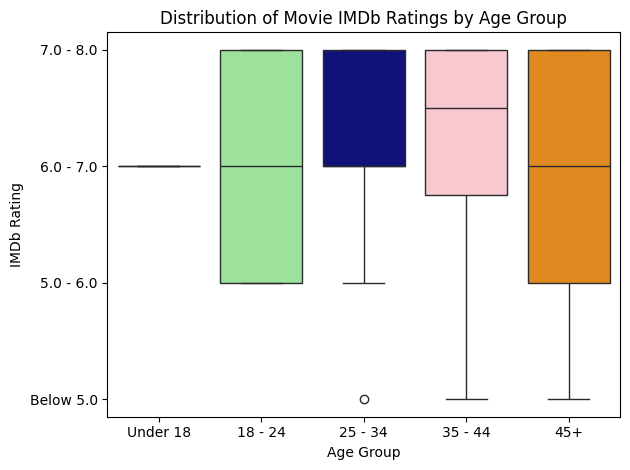

In [21]:
import pandas as pd
from pandas.plotting import register_matplotlib_converters
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np

v_age_group_order = ['Under 18', '18 - 24', '25 - 34', '35 - 44', '45+']
v_imdb_rating_order = ['7.0 - 8.0', '6.0 - 7.0', '5.0 - 6.0', 'Below 5.0']

v_age_group_colors = {
    'Under 18': 'orange',
    '18 - 24': 'lightgreen',
    '25 - 34': 'darkblue',
    '35 - 44': 'pink',
    '45+': 'darkorange'
}

# reorder age groups and IMDb ratings
survey_data['What is your age group?'] = pd.Categorical(survey_data['What is your age group?'], categories=v_age_group_order, ordered=True)
survey_data['What is your minimum acceptable IMDb rating when deciding to watch a movie?'] = pd.Categorical(survey_data['What is your minimum acceptable IMDb rating when deciding to watch a movie?'], categories=v_imdb_rating_order, ordered=True)

sns.boxplot(x='What is your age group?',
            y='What is your minimum acceptable IMDb rating when deciding to watch a movie?',
            data=survey_data,
            hue='What is your age group?',
            palette=v_age_group_colors)

plt.title('Distribution of Movie IMDb Ratings by Age Group')
plt.xlabel('Age Group')
plt.ylabel('IMDb Rating')
plt.savefig('IMDb_Ratings_Age_Group_chart.jpeg', dpi=300)
plt.tight_layout()
plt.show()

## Age Group of Survey Participants

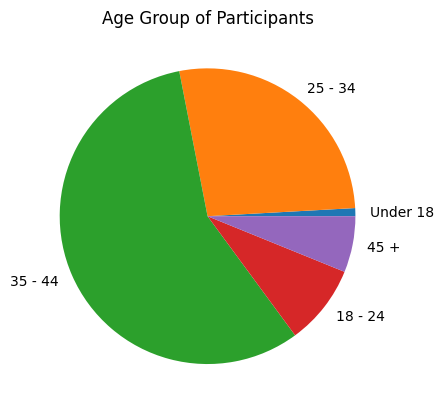

,count
What is your age group?,
25 - 34,65
18 - 24,31
35 - 44,10
45+,7
Under 18,1


In [22]:
v_data = survey_data["What is your age group?"]
v_age_group_counts = survey_data["What is your age group?"].value_counts()

v_labels = ['Under 18','25 - 34', '35 - 44', '18 - 24', '45 +']
v_sizes = [v_age_group_counts['Under 18'], v_age_group_counts['18 - 24'], v_age_group_counts['25 - 34'], v_age_group_counts['35 - 44'], v_age_group_counts['45+']]

plt.title("Age Group of Participants")
plt.pie(v_sizes, labels = v_labels)
plt.savefig('Age_Group_chart.jpeg', dpi=300)
plt.show()
v_age_group_counts

## Gender of Survey Participants

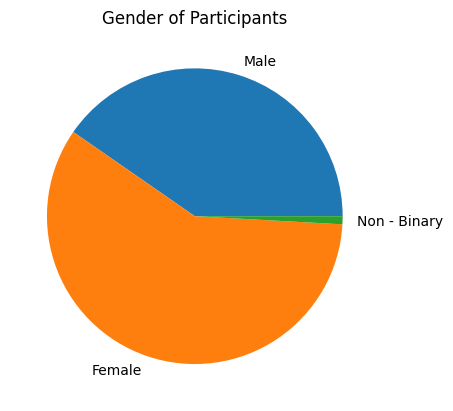

,count
What is your gender?,
Female,67
Male,46
Non - Binary,1


In [23]:
v_data = survey_data["What is your gender?"]
v_gender_counts = survey_data["What is your gender?"].value_counts()

v_labels = ['Male','Female', 'Non - Binary']
v_sizes = [v_gender_counts['Male'], v_gender_counts['Female'], v_gender_counts['Non - Binary']]

plt.title("Gender of Participants")
plt.pie(v_sizes, labels = v_labels)
plt.savefig('gender_chart.jpeg', dpi=300)
plt.show()

v_gender_counts

## Preferred Platforms by Survey Participants

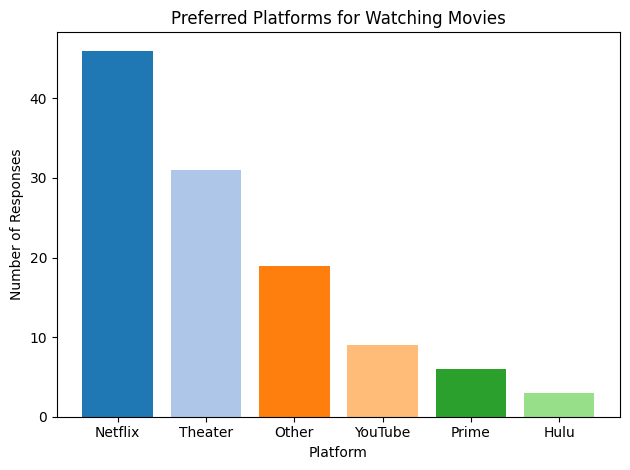

,count
What is your preferred platform for watching a movie?,
Netflix,46
Theater,31
Other,19
YouTube,9
Prime,6
Hulu,3


In [24]:
v_platforms = survey_data["What is your preferred platform for watching a movie?"]
v_platform_counts = v_platforms.value_counts()

v_colors = plt.cm.tab20.colors # set up colors

fig, ax = plt.subplots()
bars = ax.bar(v_platform_counts.index, v_platform_counts.values, color=v_colors[:len(v_platform_counts)])

ax.set_xlabel('Platform')
ax.set_ylabel('Number of Responses')
ax.set_title('Preferred Platforms for Watching Movies')

plt.savefig('platforms_chart.jpeg', dpi=300)
plt.tight_layout()
plt.show()

v_platform_counts

## Top Movie Genres

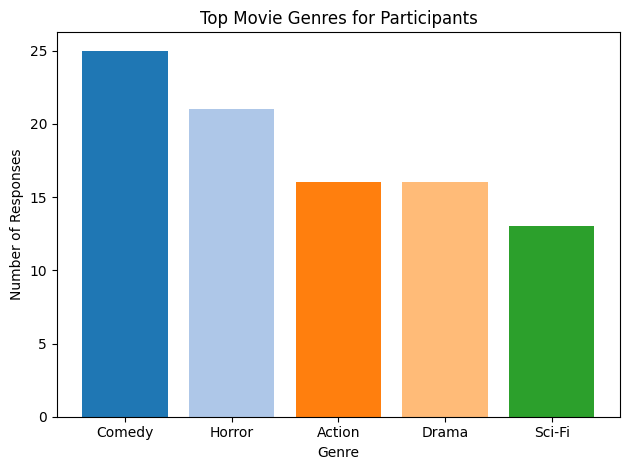

,0
Comedy,25
Horror,21
Action,16
Drama,16
Sci-Fi,13


In [28]:
v_movie_genre = survey_data.iloc[:,[10, 11, 12, 13, 14]]
v_movie_genre.columns = ['Action','Drama', 'Comedy', 'Horror', 'Sci-Fi']

v_rank_counts = {}

for v_genre in v_movie_genre.columns:
    v_counts = v_movie_genre[v_genre].value_counts()
    v_rank_counts[v_genre] = v_counts.get(1) # count only the top rankings

v_rank_counts = pd.Series(v_rank_counts)
v_rank_counts = v_rank_counts.sort_values(ascending=False)

v_colors = plt.cm.tab20.colors # set up colors

fig, ax = plt.subplots()
bars = ax.bar(v_rank_counts.index, v_rank_counts.values, color=v_colors[:len(v_rank_counts)])

ax.set_xlabel('Genre')
ax.set_ylabel('Number of Responses')
ax.set_title('Top Movie Genres for Participants')

plt.savefig('movie_genre_rankings_chart.jpeg', dpi=300)
plt.tight_layout()
plt.show()

v_rank_counts

## Top Movie Genres by Age Groups

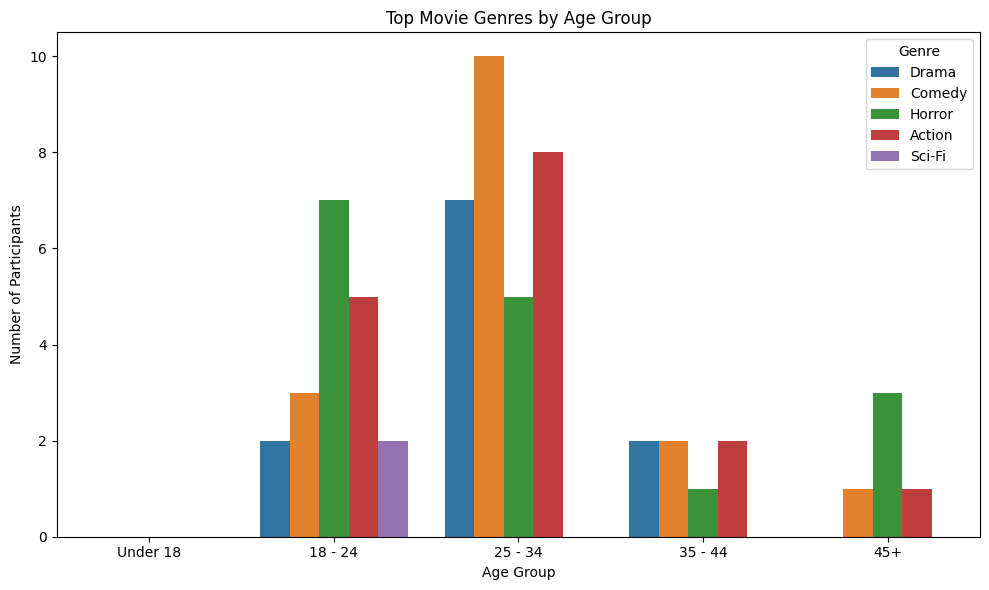

,What is your age group?,Action,Drama,Comedy,Horror,Sci-Fi,top_genre
0,25 - 34,5.0,1.0,2.0,3.0,4.0,Drama
1,25 - 34,2.0,5.0,1.0,4.0,3.0,Comedy
2,25 - 34,2.0,3.0,1.0,3.0,2.0,Comedy
3,25 - 34,4.0,2.0,3.0,1.0,5.0,Horror
4,25 - 34,4.0,4.0,4.0,2.0,4.0,None
...,...,...,...,...,...,...,...
109,25 - 34,2.0,1.0,1.0,3.0,1.0,Drama
110,18 - 24,1.0,5.0,2.0,4.0,3.0,Action
111,25 - 34,2.0,3.0,3.0,2.0,2.0,None
112,25 - 34,4.0,3.0,5.0,4.0,5.0,None


In [31]:
v_movie_genre = survey_data.iloc[:,[2, 10, 11, 12, 13, 14]]

v_new_column_names = {
    v_movie_genre.columns[1]: 'Action',
    v_movie_genre.columns[2]: 'Drama',
    v_movie_genre.columns[3]: 'Comedy',
    v_movie_genre.columns[4]: 'Horror',
    v_movie_genre.columns[5]: 'Sci-Fi'
}
v_movie_genre = v_movie_genre.rename(columns=v_new_column_names)
v_genre_columns = ['Action', 'Drama', 'Comedy', 'Horror', 'Sci-Fi']

def get_top_genre_column(row):
    for column in v_genre_columns:
        if row[column] == 1.0:
            return column
    return None

v_movie_genre_copy = v_movie_genre.copy()
v_movie_genre_copy['top_genre'] = v_movie_genre_copy.apply(get_top_genre_column, axis=1)
v_movie_genre_copy.head()

v_x = v_movie_genre_copy.iloc[:,0]
v_y = v_movie_genre_copy.iloc[:,6]

plt.figure(figsize=(10, 6))
sns.countplot(x=v_x, hue=v_y, data=v_movie_genre_copy)
plt.title('Top Movie Genres by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Participants')
plt.tight_layout()
plt.legend(title='Genre')
plt.savefig('top_movie_genres_by_age_group.jpeg', dpi=300)
plt.show()

v_movie_genre_copy


## Top Movie Factors by Age Group

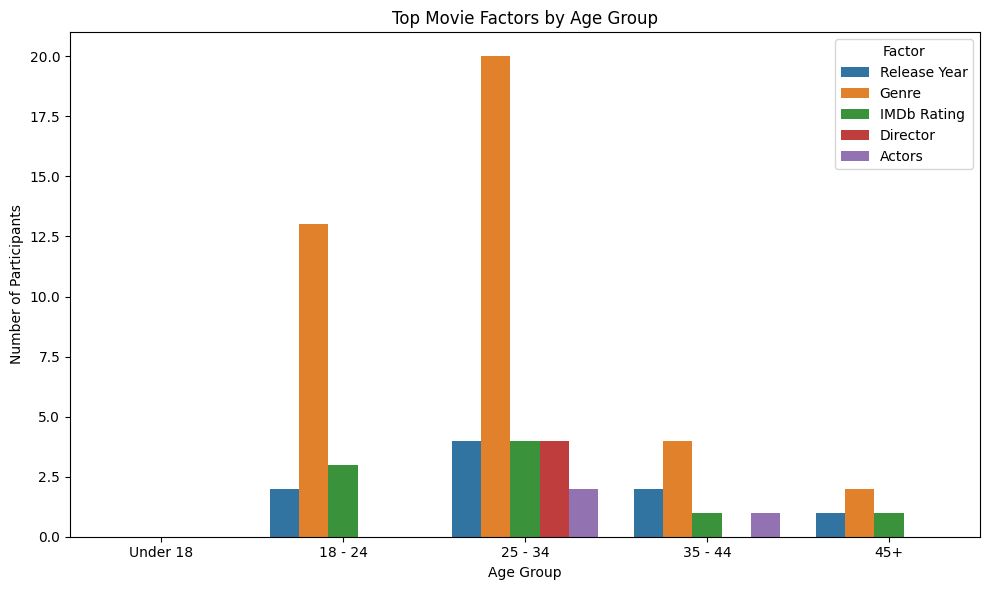

In [ ]:
v_movie_factor = survey_data.iloc[:,[2, 15, 16, 17, 18, 19]]

v_new_column_names = {
    v_movie_factor.columns[1]: 'Genre',
    v_movie_factor.columns[2]: 'IMDb Rating',
    v_movie_factor.columns[3]: 'Release Year',
    v_movie_factor.columns[4]: 'Director',
    v_movie_factor.columns[5]: 'Actors'
}
v_movie_factor = v_movie_factor.rename(columns=v_new_column_names)
v_factor_columns = ['Genre', 'IMDb Rating', 'Release Year', 'Director', 'Actors']

def get_top_factor_column(row):
    for column in v_factor_columns:
        if row[column] == 1.0:
            return column
    return None

v_movie_factor_copy = v_movie_factor.copy()
v_movie_factor_copy['top_factor'] = v_movie_factor_copy.apply(get_top_factor_column, axis=1)
v_movie_factor_copy.head()

v_x = v_movie_factor_copy.iloc[:,0]
v_y = v_movie_factor_copy.iloc[:,6]

plt.figure(figsize=(10, 6))
sns.countplot(x=v_x, hue=v_y, data=v_movie_factor_copy)
plt.title('Top Movie Factors by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Participants')
plt.tight_layout()
plt.legend(title='Factor')
plt.savefig('top_movie_factors_by_age_group.jpeg', dpi=300)
plt.show()


## Top Movie Factors

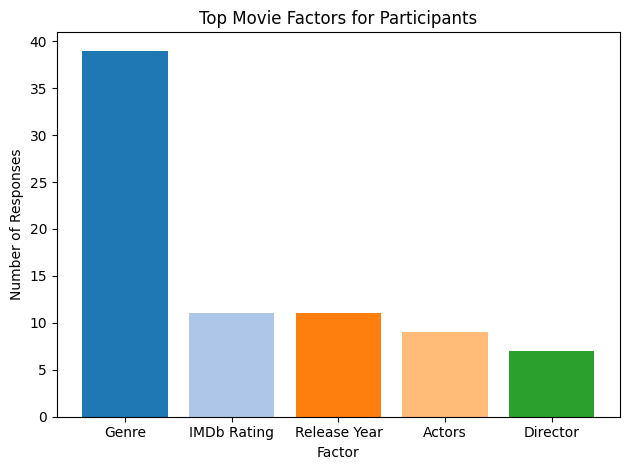

,0
Genre,39
IMDb Rating,11
Release Year,11
Actors,9
Director,7


In [30]:
v_movie_factors = survey_data.iloc[:,[15, 16, 17, 18, 19]]
v_movie_factors.columns = ['Genre','IMDb Rating', 'Release Year', 'Director', 'Actors']

v_rank_counts = {}
for v_factor in v_movie_factors.columns:
    v_counts = v_movie_factors[v_factor].value_counts()
    v_rank_counts[v_factor] = v_counts.get(1, 0) # count only the top rankings

v_rank_counts = pd.Series(v_rank_counts)
v_rank_counts = v_rank_counts.sort_values(ascending=False)

v_colors = plt.cm.tab20.colors # set up colors

fig, ax = plt.subplots()
bars = ax.bar(v_rank_counts.index, v_rank_counts.values, color=v_colors[:len(v_rank_counts)])

ax.set_xlabel('Factor')
ax.set_ylabel('Number of Responses')
ax.set_title('Top Movie Factors for Participants')

plt.savefig('movie_factors_rankings_chart.jpeg', dpi=300)
plt.tight_layout()
plt.show()

v_rank_counts

## Public Ratings vs Critics Reviews

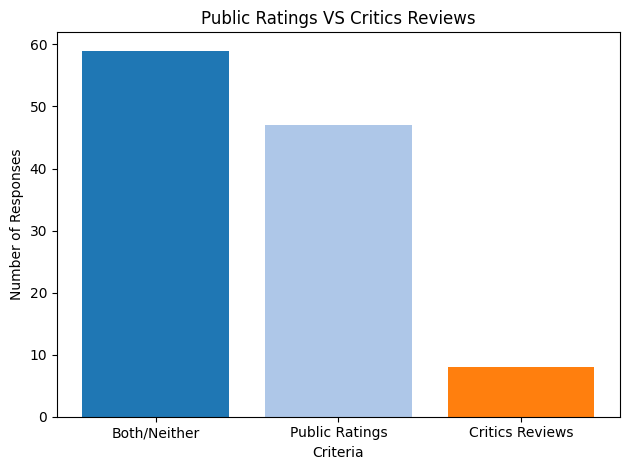

,count
Do you rely more on public ratings or reviews from critics?,
Neither / Both equally,59
"Public ratings (e.g., IMDb)",47
"Critic reviews (e.g., Rotten Tomatoes)",8


In [32]:
v_ratings_criteria = survey_data['Do you rely more on public ratings or reviews from critics?']
v_ratings_criteria_counts = v_ratings_criteria.value_counts()

v_colors = plt.cm.tab20.colors # set up colors

fig, ax = plt.subplots()
bars = ax.bar(v_ratings_criteria_counts.index, v_ratings_criteria_counts.values, color=v_colors[:len(v_ratings_criteria_counts)])

ax.set_xlabel('Criteria')
ax.set_ylabel('Number of Responses')
ax.set_title('Public Ratings VS Critics Reviews')
ax.set_xticks(range(len(v_ratings_criteria_counts.index))) # change x-axis labels
ax.set_xticklabels(['Both/Neither', 'Public Ratings', 'Critics Reviews'])

plt.savefig('ratings_criteria_chart.jpeg', dpi=300)
plt.tight_layout()
plt.show()

v_ratings_criteria_counts

## Average Number of Movies Survey that Participants Watch in a Month

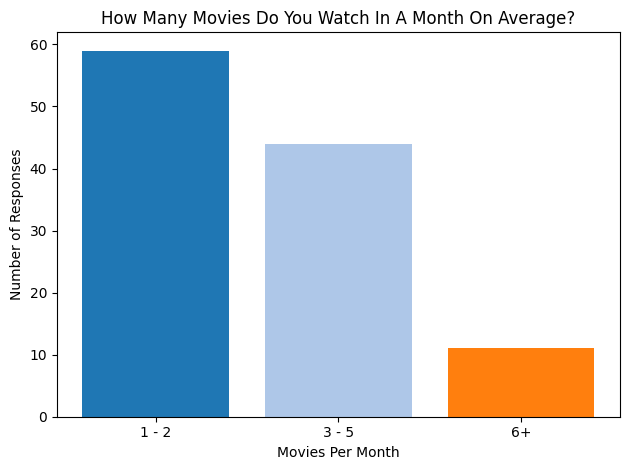

,count
How many movies do you watch in a month on average?,
1 - 2,59
3 - 5,44
6+,11


In [29]:
v_movies_per_month = survey_data['How many movies do you watch in a month on average?']
v_movies_per_month_counts = v_movies_per_month.value_counts()

v_colors = plt.cm.tab20.colors # set up colors

fig, ax = plt.subplots()
bars = ax.bar(v_movies_per_month_counts.index, v_movies_per_month_counts.values, color=v_colors[:len(v_movies_per_month_counts)])

ax.set_xlabel('Movies Per Month')
ax.set_ylabel('Number of Responses')
ax.set_title('How Many Movies Do You Watch In A Month On Average?')

ax.set_xticks(range(len(v_movies_per_month_counts.index))) # change x-axis labels
ax.set_xticklabels(['1 - 2', '3 - 5', '6+'])

plt.savefig('movies_per_month.jpeg', dpi=300)
plt.tight_layout()
plt.show()

v_movies_per_month_counts

## Preferred Movies, Given Title, IMDb Ratings, Year of Release, Director and Actor - Chart 1

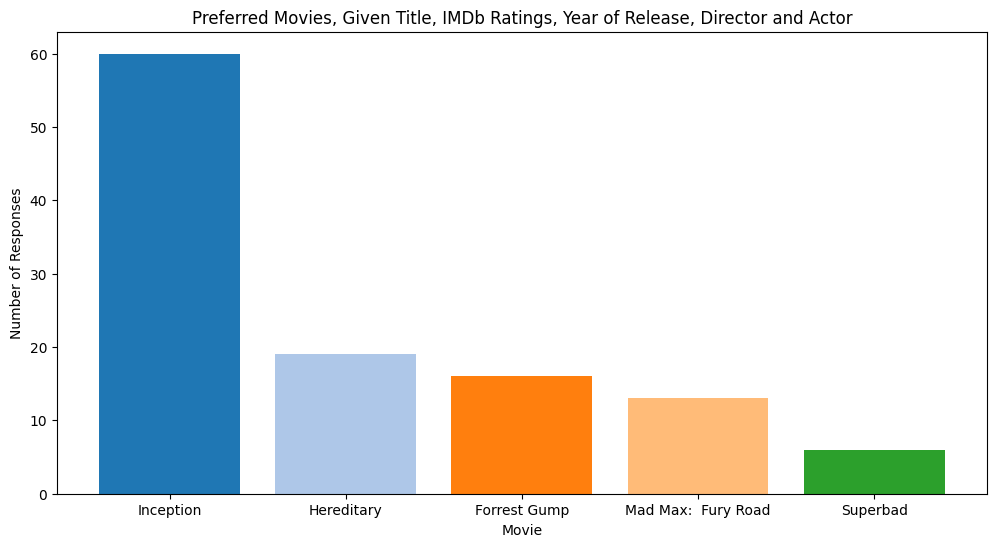

,count
"Given the details of Title, IMDb Rating, Year of Release, Director and Actor, Which of the following movies would you pick?",
"Inception, IMDb Rating: 8.8, Year: 2010, Director: Christopher Nolan, Actors: Leonardo DiCaprio, Joseph Gordon-Levitt",60
"Hereditary, IMDb Rating: 7.3, Year: 2018, Director: Ari Aster, Actors: Toni Collette, Milly Shapiro",19
"Forrest Gump, IMDb Rating: 8.8, Year: 1994, Director: Robert Zemeckis, Actors: Tom Hanks, Robin Wright, Gary Sinise",16
"Mad Max: Fury Road, IMDb Rating : 8.1, Year: 2015, Director: George Miller, Actors: Tom Hardy, Charlize Theron, Nicholas Hoult",13
"Superbad, IMDb Rating: 7.6, Year: 2007, Director: Greg Mottola, Actors: Michael Cera, Jonah Hill",6


In [ ]:
v_movies = survey_data.iloc[:,20]
v_movie_counts = v_movies.value_counts()

v_colors = plt.cm.tab20.colors # set up colors

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(v_movie_counts.index, v_movie_counts.values, color=v_colors[:len(v_movie_counts)])

ax.set_xlabel('Movie')
ax.set_ylabel('Number of Responses')
ax.set_title('Preferred Movies, Given Title, IMDb Ratings, Year of Release, Director and Actor')

ax.set_xticks(range(len(v_movie_counts.index))) # change x-axis labels
ax.set_xticklabels(['Inception', 'Hereditary', 'Forrest Gump', 'Mad Max:  Fury Road', 'Superbad'])

plt.savefig('preferred_movies_chart1.jpeg', dpi=300)
plt.show()
v_movie_counts

## Preferred Movies, Given Title, IMDb Ratings, Year of Release, Director and Actor - Chart 2

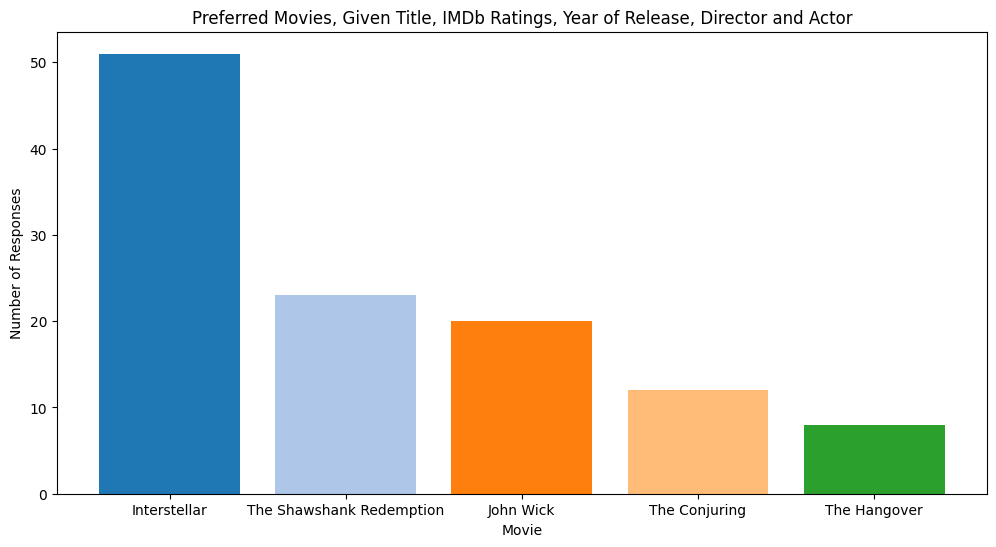

,count
"Given the details of Title, IMDb Rating, Year of Release, Director and Actor, Which of the following movies would you pick?.1",
"Interstellar, IMDb Rating: 8.7, Year: 2014, Director: Christopher Nolan, Actors: Matthew McConaughey, Anne Hathaway, Jessica Chastain",51
"The Shawshank Redemption, IMDb Rating: 9.3, Year: 1994, Director: Frank Darabont, Actors: Tim Robbins, Morgan Freeman, Bob Gunton",23
"John Wick, IMDb Rating: 7.4, Year: 2014, Director: Chad Stahelski, Actors: Keanu Reeves, Michael Nyqvist, Alfie Allen",20
"The Conjuring, IMDb Rating: 7.5, Year: 2013, Director: James Wan, Actors: Patrick Wilson, Vera Farmiga, Ron Livingston",12
"The Hangover, IMDb Rating: 7.7, Year: 2009, Director: Todd Phillips, Actors: Zach Galifianakis, Bradley Cooper, Justin Bartha",8


In [ ]:
v_movies = survey_data.iloc[:,21]
v_movie_counts = v_movies.value_counts()

v_colors = plt.cm.tab20.colors # set up colors

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(v_movie_counts.index, v_movie_counts.values, color=v_colors[:len(v_movie_counts)])

ax.set_xlabel('Movie')
ax.set_ylabel('Number of Responses')
ax.set_title('Preferred Movies, Given Title, IMDb Ratings, Year of Release, Director and Actor')

ax.set_xticks(range(len(v_movie_counts.index))) # change x-axis labels
ax.set_xticklabels(['Interstellar', 'The Shawshank Redemption', 'John Wick', 'The Conjuring', 'The Hangover'])

plt.savefig('preferred_movies_chart2.jpeg', dpi=300)
plt.show()
v_movie_counts

## Preferred Movies, Given Title, IMDb Ratings, Year of Release, Director and Actor - Chart 3

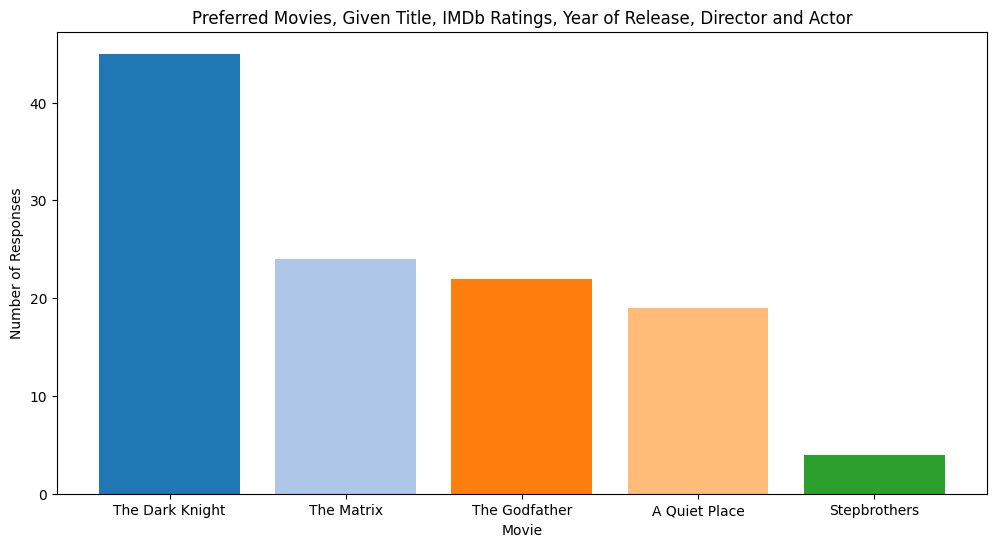

,count
"Given the details of Title, IMDb Rating, Year of Release, Director and Actor, Which of the following movies would you pick?.2",
"The Dark Knight, IMDb Rating: 9.0, Year: 2008, Director: Christopher Nolan, Actors: Christian Bale, Heath Ledger, Aaron Eckhart",45
"The Matrix, IMDb Rating: 8.7, Year: 1999, Director: Lana Wachowski, Lilly Wachowski, Actors: Keanu Reeves, Laurence Fishburne, Carrie-Anne Moss",24
"The Godfather, IMDb Rating: 9.2, Year: 1972, Director: Francis Ford Coppola, Actors: Marlon Brando, Al Pacino, James Caan",22
"A Quiet Place, IMDb Rating: 7.5, Year: 2018, Director: John Krasinski, Actors: Emily Blunt, John Krasinski, Millicent Simmonds",19
"Step Brothers, IMDb Rating: 6.9, Year: 2008, Director: Adam McKay, Actors: Will Ferrell, John C. Reilly, Mary Steenburgen",4


In [ ]:
v_movies = survey_data.iloc[:,22]
v_movie_counts = v_movies.value_counts()

v_colors = plt.cm.tab20.colors # set up colors

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(v_movie_counts.index, v_movie_counts.values, color=v_colors[:len(v_movie_counts)])

ax.set_xlabel('Movie')
ax.set_ylabel('Number of Responses')
ax.set_title('Preferred Movies, Given Title, IMDb Ratings, Year of Release, Director and Actor')

ax.set_xticks(range(len(v_movie_counts.index))) # change x-axis labels
ax.set_xticklabels(['The Dark Knight', 'The Matrix', 'The Godfather', 'A Quiet Place', 'Stepbrothers'])

plt.savefig('preferred_movies_chart3.jpeg', dpi=300)
plt.show()
v_movie_counts

## Cleaning data on the  survey spreadsheet and merging with movies data

Define question columns: 20 to 23

In [ ]:
question_columns = survey_data.columns[20:24]

Normalize the movie choices (strip spaces and convert to lowercase)

In [ ]:
movie_choices = movies.tolist()
movie_choices = [movie.strip().lower() for movie in movie_choices]

Extract only the movie name from the full description (e.g., "Mad Max: Fury Road, IMDb Rating: 8.1..." -> "Mad Max: Fury Road")


In [ ]:
def extract_movie_name(movie_description):
    # Improved regex to capture everything before the first comma (before IMDb rating)
    match = re.match(r"^([^,]+)(?=,|$)", movie_description)
    return match.group(1).strip().lower() if match else movie_description.strip().lower()

Normalize the responses in question columns by extracting the movie name

In [ ]:
survey_data[question_columns] = survey_data[question_columns].apply(
    lambda x: x.apply(extract_movie_name) if x.dtype == 'object' else x
)

Create new columns for each movie choice, initialized to 0

In [ ]:
for movie in movie_choices:
    survey_data[movie] = 0

Loop through each of the question columns (21-23) and update the counts

In [ ]:
for question_column in question_columns:
    for movie in movie_choices:
        # Compare the extracted movie name with the responses and update the count
        survey_data[movie] += (survey_data[question_column] == movie).astype(int)


Display the updated DataFrame with count columns

In [ ]:
survey_data.head()

,Timestamp,What is your gender?,What is your age group?,What is your preferred platform for watching a movie?,Do you rely more on public ratings or reviews from critics?,What is your minimum acceptable IMDb rating when deciding to watch a movie?,How many movies do you watch in a month on average?,How much do you trust IMDb ratings as a reflection of a movie's quality?,Have you skipped a movie solely because of a low rating?,Have you ever enjoyed a movie that had a low rating?,...,"Given the details of Title, IMDb Rating, Year of Release, Director and Actor, Which of the following movies would you pick?.2","If a movie has a rating of 5.5 but your favorite actor stars in it, would you still watch it?","If a movie has a 9.5 rating but it's a genre you usually avoid, would you still give it a try?",Would a well-known director make you more willing to watch a movie in a genre you don’t usually enjoy?,"If a movie from your favorite genre had a bad IMDb score, would you skip it or still give it a shot?","a quiet place, imdb rating: 7.5, year: 2018, director: john krasinski, actors: emily blunt, john krasinski, millicent simmonds","the dark knight, imdb rating: 9.0, year: 2008, director: christopher nolan, actors: christian bale, heath ledger, aaron eckhart","the godfather, imdb rating: 9.2, year: 1972, director: francis ford coppola, actors: marlon brando, al pacino, james caan","the matrix, imdb rating: 8.7, year: 1999, director: lana wachowski, lilly wachowski, actors: keanu reeves, laurence fishburne, carrie-anne moss","step brothers, imdb rating: 6.9, year: 2008, director: adam mckay, actors: will ferrell, john c. reilly, mary steenburgen"
0,4/18/2025 22:55:57,Female,25 - 34,Netflix,Neither / Both equally,6.0 - 7.0,3 - 5,4.0,Yes,Yes,...,a quiet place,3.0,5.0,4.0,3.0,0,0,0,0,0
1,4/18/2025 23:00:37,Male,25 - 34,Theater,Neither / Both equally,6.0 - 7.0,3 - 5,3.0,Yes,Yes,...,the dark knight,3.0,4.0,3.0,4.0,0,0,0,0,0
2,4/18/2025 23:04:46,Male,25 - 34,Netflix,"Public ratings (e.g., IMDb)",6.0 - 7.0,6+,4.0,Yes,Yes,...,the dark knight,5.0,2.0,3.0,4.0,0,0,0,0,0
3,4/18/2025 23:05:49,Female,25 - 34,Theater,"Public ratings (e.g., IMDb)",7.0 - 8.0,3 - 5,4.0,Yes,Yes,...,the dark knight,4.0,1.0,3.0,5.0,0,0,0,0,0
4,4/18/2025 23:11:55,Female,25 - 34,Other,Neither / Both equally,7.0 - 8.0,1 - 2,5.0,Yes,No,...,the godfather,1.0,3.0,4.0,1.0,0,0,0,0,0


Save the updated DataFrame to a new CSV file

In [ ]:
survey_data.to_csv('updated_responses.csv', index=False)

### Read and view the updated survey info

In [ ]:
update_responses = pd.read_csv('updated_responses.csv')
update_responses.head()

,Timestamp,What is your gender?,What is your age group?,What is your preferred platform for watching a movie?,Do you rely more on public ratings or reviews from critics?,What is your minimum acceptable IMDb rating when deciding to watch a movie?,How many movies do you watch in a month on average?,How much do you trust IMDb ratings as a reflection of a movie's quality?,Have you skipped a movie solely because of a low rating?,Have you ever enjoyed a movie that had a low rating?,...,"Given the details of Title, IMDb Rating, Year of Release, Director and Actor, Which of the following movies would you pick?.2","If a movie has a rating of 5.5 but your favorite actor stars in it, would you still watch it?","If a movie has a 9.5 rating but it's a genre you usually avoid, would you still give it a try?",Would a well-known director make you more willing to watch a movie in a genre you don’t usually enjoy?,"If a movie from your favorite genre had a bad IMDb score, would you skip it or still give it a shot?","a quiet place, imdb rating: 7.5, year: 2018, director: john krasinski, actors: emily blunt, john krasinski, millicent simmonds","the dark knight, imdb rating: 9.0, year: 2008, director: christopher nolan, actors: christian bale, heath ledger, aaron eckhart","the godfather, imdb rating: 9.2, year: 1972, director: francis ford coppola, actors: marlon brando, al pacino, james caan","the matrix, imdb rating: 8.7, year: 1999, director: lana wachowski, lilly wachowski, actors: keanu reeves, laurence fishburne, carrie-anne moss","step brothers, imdb rating: 6.9, year: 2008, director: adam mckay, actors: will ferrell, john c. reilly, mary steenburgen"
0,4/18/2025 22:55:57,Female,25 - 34,Netflix,Neither / Both equally,6.0 - 7.0,3 - 5,4.0,Yes,Yes,...,a quiet place,3.0,5.0,4.0,3.0,0,0,0,0,0
1,4/18/2025 23:00:37,Male,25 - 34,Theater,Neither / Both equally,6.0 - 7.0,3 - 5,3.0,Yes,Yes,...,the dark knight,3.0,4.0,3.0,4.0,0,0,0,0,0
2,4/18/2025 23:04:46,Male,25 - 34,Netflix,"Public ratings (e.g., IMDb)",6.0 - 7.0,6+,4.0,Yes,Yes,...,the dark knight,5.0,2.0,3.0,4.0,0,0,0,0,0
3,4/18/2025 23:05:49,Female,25 - 34,Theater,"Public ratings (e.g., IMDb)",7.0 - 8.0,3 - 5,4.0,Yes,Yes,...,the dark knight,4.0,1.0,3.0,5.0,0,0,0,0,0
4,4/18/2025 23:11:55,Female,25 - 34,Other,Neither / Both equally,7.0 - 8.0,1 - 2,5.0,Yes,No,...,the godfather,1.0,3.0,4.0,1.0,0,0,0,0,0


### Create a dictionary to store counts for each movie's selection


In [ ]:
movies= pd.read_csv('movies.csv')
movies['Title'] = movies['Title'].str.strip().str.lower()
movie_choices = update_responses.columns[-15:]
movie_counts = {movie: update_responses[movie].sum() for movie in movie_choices}

Convert the movie_counts dictionary to a DataFrame

In [ ]:
movie_counts_df = pd.DataFrame(list(movie_counts.items()), columns=['Movie', 'Count'])
movie_counts_df.head()

,Movie,Count
0,Rank each of these factors from 1-5 based on w...,381.0
1,Rank each of these factors from 1-5 based on w...,402.0
2,Rank each of these factors from 1-5 based on w...,369.0
3,"Given the details of Title, IMDb Rating, Year ...",inceptioninceptionmad max: fury roadmad max: f...
4,"Given the details of Title, IMDb Rating, Year ...",john wickthe shawshank redemptioninterstellart...


Remove extra spaces and convert to lowercase to ensure matching

In [ ]:
movies['Title'] = movies['Title'].str.strip().str.lower()
movie_counts_df['Movie'] = movie_counts_df['Movie'].str.strip().str.lower()

Merging the cleaned data with the original data frame "movies" and saving it as "movies2_df"

In [ ]:
movies2_df = movies.merge(movie_counts_df, left_on='Title', right_on='Movie', how='left')
movies2_df

,Title,Genre,IMDb Rating,Year,Director,Actors,Movie,Count
0,mad max: fury road,Action,8.1,2015,George Miller,"Tom Hardy, Charlize Theron, Nicholas Hoult",NaN,NaN
1,john wick,Action,7.4,2014,Chad Stahelski,"Keanu Reeves, Michael Nyqvist, Alfie Allen",NaN,NaN
2,the dark knight,Action,9.0,2008,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart",NaN,NaN
3,forrest gump,Drama,8.8,1994,Robert Zemeckis,"Tom Hanks, Robin Wright, Gary Sinise",NaN,NaN
4,the shawshank redemption,Drama,9.3,1994,Frank Darabont,"Tim Robbins, Morgan Freeman, Bob Gunton",NaN,NaN
5,the godfather,Drama,9.2,1972,Francis Ford Coppola,"Marlon Brando, Al Pacino, James Caan",NaN,NaN
6,superbad,Comedy,7.6,2007,Greg Mottola,"Michael Cera, Jonah Hill, Christopher Mintz-Pl...",NaN,NaN
7,the hangover,Comedy,7.7,2009,Todd Phillips,"Zach Galifianakis, Bradley Cooper, Justin Bartha",NaN,NaN
8,step brothers,Comedy,6.9,2008,Adam McKay,"Will Ferrell, John C. Reilly, Mary Steenburgen",NaN,NaN
9,hereditary,Horror,7.3,2018,Ari Aster,"Toni Collette, Milly Shapiro, Gabriel Byrne",NaN,NaN


### Creating Dummy Variables

Converting "Genre" into categorical variables by genrating dummy variables for each "Action","Darama","Comedy","Horror" and "Science Fiction".
Yes = 1
No= 0

In [ ]:
genre_dummies = pd.get_dummies(movies2_df['Genre'], prefix='Genre',dtype=int)

# Concatenate the dummy variables with the original DataFrame
movies2_df = pd.concat([movies2_df, genre_dummies], axis=1)

# Display the updated DataFrame
movies2_df.head()


# Linear Regression

Building a linear model to assess the importance of each factor on the number of views they will get


## Data Split 75-25


In [ ]:
X = movies2_df[['Genre_Action', 'Genre_Comedy', 'Genre_Drama', 'Genre_Horror', 'Genre_Science Fiction', 'IMDb Rating','Year']]
y = movies2_df['Count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) # 75% training, 25% test, random_state for reproducibility

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

## Training the base model

In [ ]:
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Add a constant to the independent variables (intercept)
X = sm.add_constant(X)

# Fit the linear regression model using the training data
model1 = sm.OLS(y_train, X_train).fit()

# Print the model summary
print(model1.summary())


Making a prediction

In [ ]:
# Make predictions on the test data
predictions = model1.predict(X_test)

## Calculating RMSE

In [ ]:
from sklearn.metrics import mean_squared_error
rmse = (mean_squared_error(y_test, predictions)**0.5)
print(f"Root Mean Squared Error (RMSE): {rmse}")